In [1]:
library(stringr)
library(RColorBrewer)
library(parallel)

Warning message:
“package ‘stringr’ was built under R version 4.3.2”


In [2]:
library(patchwork)

Warning message:
“package ‘patchwork’ was built under R version 4.3.2”


In [3]:
pcas_new = read.table('/nfs/lab/projects/nash_nafld_liver/genotypes/pca/FNIH.Liver.1KGP.merge.filt.pruned.pca.eigenvec', header=T)

dim(pcas_new)
head(pcas_new)
tail(pcas_new)

[1] 2643   22

,FID,IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,⋯,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,FNIH-Liver-HL170044-10252023,FNIH-Liver-HL170044-10252023,-0.0128442,0.01731450,-0.00276722,0.01341930,-0.00297114,-0.03327060,0.005593500,-0.00723718,⋯,-7.19899e-05,-0.001329010,-0.00209108,-4.66598e-05,-0.002485250,-0.000153592,-0.00162075,0.00269623,-0.00658605,0.00442406
2,FNIH-Liver-HL200529-02262024,FNIH-Liver-HL200529-02262024,-0.0101794,0.00379363,0.04251670,-0.00601031,-0.00585492,0.01142840,-0.000537141,-0.02680360,⋯,-2.11514e-02,0.006590430,0.06852840,1.74679e-02,0.017600000,0.019951500,0.05276110,0.00260610,0.01035930,-0.05125990
3,FNIH-Liver-HL230212-02262024,FNIH-Liver-HL230212-02262024,-0.0115252,0.00270929,0.04027980,-0.00646665,-0.00351872,0.00984427,-0.001876060,-0.00280998,⋯,7.49328e-03,0.000702172,-0.00483281,-9.42175e-04,0.003512520,-0.009128060,-0.02640840,-0.00646756,-0.00665964,0.04963740
4,FNIH-Liver-HL200425-08012023,FNIH-Liver-HL200425-08012023,-0.0117799,0.02115520,0.00365417,0.01114620,-0.00117555,0.02554120,-0.004748250,-0.00258136,⋯,7.13344e-03,0.005267980,0.00183767,4.33877e-04,0.000456243,0.001280060,0.00583747,0.00561541,-0.00250980,0.00333598
5,FNIH-Liver-HL220210-08012023,FNIH-Liver-HL220210-08012023,-0.0130326,0.02786760,-0.00304587,0.01904260,-0.00433175,-0.02742570,0.001169230,0.01269880,⋯,5.23638e-03,0.439263000,-0.50178200,-4.04564e-02,0.107198000,-0.053453000,-0.12419200,-0.01546080,0.02736510,-0.02013180
6,FNIH-Liver-HL220405-02262024,FNIH-Liver-HL220405-02262024,-0.0129373,0.02725600,-0.00437228,0.01950440,-0.00512447,-0.02138940,0.001285220,0.00251837,⋯,7.41810e-02,-0.027916000,0.15267700,1.00204e-01,0.651950000,-0.052405200,-0.10917100,-0.02011430,0.02557020,-0.03492580


,FID,IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,⋯,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2638,NA21135,NA21135,-0.0105080,0.00445464,-0.0186953,-0.0376208,0.00316689,-0.000404744,-0.001141500,-0.001583600,⋯,0.001021040,0.000536057,0.00272329,-0.004100780,-0.00356797,0.004270260,0.0224024,5.04023e-05,0.00411404,-0.003600620
2639,NA21137,NA21137,-0.0107049,0.00472298,-0.0178477,-0.0373185,0.00182397,-0.000125734,-0.000780334,-0.000674748,⋯,-0.001776090,0.001827510,0.00257114,-0.000693214,0.00582141,0.003266830,0.0180280,-5.34825e-04,0.00280433,0.000303209
2640,NA21141,NA21141,-0.0107468,0.00429926,-0.0182483,-0.0372690,0.00161430,-0.004076070,-0.001127290,0.000582676,⋯,0.000657145,0.005877680,0.00336587,0.000589818,-0.00564920,0.000668101,0.0150194,-4.47058e-04,0.00476528,-0.002879180
2641,NA21142,NA21142,-0.0105926,0.00405429,-0.0184156,-0.0370728,0.00269955,-0.002470630,-0.000754689,-0.001773580,⋯,-0.003103280,0.000127092,0.00139519,-0.001768360,-0.00394884,0.003812780,0.0206288,1.44359e-03,0.00245220,0.000813329
2642,NA21143,NA21143,-0.0107256,0.00369449,-0.0184133,-0.0376843,0.00182699,-0.002768760,-0.000383043,0.000325136,⋯,0.003198080,-0.000196193,-0.00333482,-0.000422450,-0.00436049,0.003309810,0.0182492,5.43877e-04,0.00469273,0.002451270
2643,NA21144,NA21144,-0.0106323,0.00392814,-0.0184864,-0.0372594,0.00256838,0.000306258,0.000323245,-0.002197680,⋯,0.001857300,0.001409220,-0.00165193,-0.004771130,-0.00279839,0.002339640,0.0163437,-4.96001e-04,0.00586766,-0.003766220


In [13]:
pcas_new$FID[str_detect(pcas_new$IID, 'HL')] <- str_extract(pcas_new$FID[str_detect(pcas_new$IID, 'HL')], "HL\\d+")
pcas_new$IID[str_detect(pcas_new$IID, 'HL')] <- str_extract(pcas_new$IID[str_detect(pcas_new$IID, 'HL')], "HL\\d+")
pcas_new

FID,IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,⋯,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HL170044,HL170044,-0.01284420,0.017314500,-0.00276722,0.01341930,-0.00297114,-0.03327060,5.59350e-03,-0.007237180,⋯,-7.19899e-05,-0.001329010,-2.09108e-03,-4.66598e-05,-0.002485250,-0.000153592,-0.00162075,2.69623e-03,-0.006586050,0.00442406
HL200529,HL200529,-0.01017940,0.003793630,0.04251670,-0.00601031,-0.00585492,0.01142840,-5.37141e-04,-0.026803600,⋯,-2.11514e-02,0.006590430,6.85284e-02,1.74679e-02,0.017600000,0.019951500,0.05276110,2.60610e-03,0.010359300,-0.05125990
HL230212,HL230212,-0.01152520,0.002709290,0.04027980,-0.00646665,-0.00351872,0.00984427,-1.87606e-03,-0.002809980,⋯,7.49328e-03,0.000702172,-4.83281e-03,-9.42175e-04,0.003512520,-0.009128060,-0.02640840,-6.46756e-03,-0.006659640,0.04963740
HL200425,HL200425,-0.01177990,0.021155200,0.00365417,0.01114620,-0.00117555,0.02554120,-4.74825e-03,-0.002581360,⋯,7.13344e-03,0.005267980,1.83767e-03,4.33877e-04,0.000456243,0.001280060,0.00583747,5.61541e-03,-0.002509800,0.00333598
HL220210,HL220210,-0.01303260,0.027867600,-0.00304587,0.01904260,-0.00433175,-0.02742570,1.16923e-03,0.012698800,⋯,5.23638e-03,0.439263000,-5.01782e-01,-4.04564e-02,0.107198000,-0.053453000,-0.12419200,-1.54608e-02,0.027365100,-0.02013180
HL220405,HL220405,-0.01293730,0.027256000,-0.00437228,0.01950440,-0.00512447,-0.02138940,1.28522e-03,0.002518370,⋯,7.41810e-02,-0.027916000,1.52677e-01,1.00204e-01,0.651950000,-0.052405200,-0.10917100,-2.01143e-02,0.025570200,-0.03492580
HL160017,HL160017,-0.01276870,0.026879400,-0.00358643,0.01741510,-0.00204888,-0.01008540,-1.20354e-03,0.000274721,⋯,3.59826e-03,0.007970290,-1.05766e-03,-4.71971e-04,0.003867660,0.004787130,0.02478210,3.64699e-03,-0.007997530,0.00747086
HL170064,HL170064,0.04364290,0.000511416,0.00306145,0.00354503,0.00831225,-0.01237850,-2.52905e-02,0.000778331,⋯,1.70658e-02,0.031716500,-3.92876e-03,1.08690e-02,0.019065400,0.030396200,-0.02945090,-8.62863e-02,-0.889368000,-0.12898600
HL220402,HL220402,-0.01231960,0.026895700,-0.00287544,0.01827230,-0.00118654,-0.00924530,-1.00328e-04,0.004390540,⋯,1.00905e-02,0.009977800,1.31812e-02,2.44233e-04,0.003860490,0.005418220,0.00937702,6.61073e-03,-0.005135000,0.00468024


In [4]:
# Read in metadata labels
sup = read.table("/nfs/lab/projects/pbmc_snATAC/pipeline/snp_array/1kg_super_population_table.tsv", sep="\t", header=T)
samp = read.table("/nfs/lab/projects/pbmc_snATAC/pipeline/snp_array/1kg_population_sample_table.tsv", sep="\t", header=T)
samp = merge(samp, sup, by.x=2, by.y=1)

In [14]:
pcas_new$FID[str_detect(pcas_new$IID, 'HL')]

[1] "HL170044" "HL200529" "HL230212" "HL200425" "HL220210" "HL220405"
 [7] "HL160017" "HL170064" "HL220402" "HL211122" "HL150015" "HL181029"
[13] "HL190114" "HL190624" "HL190114" "HL150009" "HL160026" "HL160041"
[19] "HL210207" "HL201024" "HL211025" "HL180809" "HL211001" "HL230325"
[25] "HL200529" "HL190909" "HL160037" "HL190214" "HL210614" "HL220405"
[31] "HL230324" "HL170052" "HL170062" "HL220210" "HL230324" "HL170058"
[37] "HL210521" "HL210621" "HL220216" "HL230316" "HL201024" "HL160040"
[43] "HL181031" "HL200115" "HL160029" "HL170055" "HL160035" "HL170047"
[49] "HL190215" "HL220825" "HL190827" "HL160030" "HL220613" "HL221119"
[55] "HL200805" "HL201120" "HL210727" "HL211106" "HL190326" "HL170048"
[61] "HL210706" "HL220628" "HL160042" "HL160022" "HL170065" "HL200212"
[67] "HL180069" "HL150001" "HL220127" "HL200707" "HL160032" "HL191002"
[73] "HL170046" "HL190603" "HL200525" "HL191025" "HL150013" "HL200615"
[79] "HL210726" "HL221006" "HL221201" "HL200925" "HL221019" "HL230302"
[85] "HL170049" "HL170066" "HL180071" "HL170060" "HL211122" "HL221215"
[91] "HL210806" "HL190606" "HL191216" "HL210120" "HL181010"

In [16]:
#df2 = data.frame(Sample= rownames(df)[df[,1] %in% samples], SuperPopulation.Code="Sc_Islets")
df2 = data.frame(Sample= pcas_new$FID[str_detect(pcas_new$IID, 'HL')], SuperPopulation.Code="Liver.Samples")
samp2 = rbind(samp[,2:3], df2)
samp2

Sample,SuperPopulation.Code
<chr>,<chr>
HG02308,AFR
HG02255,AFR
HG02111,AFR
HG02480,AFR
HG01894,AFR
HG02478,AFR
HG02427,AFR
HG02479,AFR
HG02451,AFR


In [17]:
library(RColorBrewer)

col=brewer.pal(6,"Paired")

In [18]:
var_new = readLines('/nfs/lab/projects/nash_nafld_liver/genotypes/pca/FNIH.Liver.1KGP.merge.filt.pruned.pca.eigenval')

var_new_expl =paste0( "PC", 1:20, " (",round((as.numeric(var_new)/sum(as.numeric(var_new)))*100,1), "%)")

samp2$SuperPopulation.Code = as.factor(samp2$SuperPopulation.Code)

In [19]:
#codes = stringr::str_split_fixed( samp2[samp2$SuperPopulation.Code=="Sc_Islets",'Sample'], "_R",2)[,2]
codes = samp2[samp2$SuperPopulation.Code=="Liver.Samples",'Sample']

In [21]:
pcas_new$labs =codes[ match( pcas_new$FID  , samp2[samp2$SuperPopulation.Code=="Liver.Samples",'Sample']  )  ]

In [29]:
pcas_new$FID[duplicated(pcas_new$FID)]

[1] "HL190114" "HL200529" "HL220405" "HL220210" "HL230324" "HL201024" "HL211122"

In [30]:
samp2$Sample[duplicated(samp2$Sample)]

[1] "HL190114" "HL200529" "HL220405" "HL220210" "HL230324" "HL201024" "HL211122"

In [31]:
pcas_new <- pcas_new[!duplicated(pcas_new$FID),]
samp2 <- samp2[!duplicated(samp2$Sample),]

In [32]:
dim(pcas_new)
dim(samp2)
dim(dplyr::left_join(pcas_new, samp2, dplyr::join_by(FID==Sample)))

[1] 2636   23

[1] 3588    2

[1] 2636   24

In [33]:
write.table(dplyr::left_join(pcas_new, samp2, dplyr::join_by(FID==Sample)),
            '/nfs/lab/projects/nash_nafld_liver/genotypes/pca/Supplemental_gPCA_data.tsv',
           sep='\t', row.names=T, col.names=T, quote=F)

In [36]:
dplyr::left_join(pcas_new, samp2, dplyr::join_by(FID==Sample))

FID,IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,⋯,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,labs,SuperPopulation.Code
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<fct>
HL170044,HL170044,-0.01284420,0.017314500,-0.00276722,0.01341930,-0.00297114,-0.03327060,5.59350e-03,-0.007237180,⋯,-2.09108e-03,-4.66598e-05,-0.002485250,-0.000153592,-0.00162075,2.69623e-03,-0.006586050,0.00442406,HL170044,Liver.Samples
HL200529,HL200529,-0.01017940,0.003793630,0.04251670,-0.00601031,-0.00585492,0.01142840,-5.37141e-04,-0.026803600,⋯,6.85284e-02,1.74679e-02,0.017600000,0.019951500,0.05276110,2.60610e-03,0.010359300,-0.05125990,HL200529,Liver.Samples
HL230212,HL230212,-0.01152520,0.002709290,0.04027980,-0.00646665,-0.00351872,0.00984427,-1.87606e-03,-0.002809980,⋯,-4.83281e-03,-9.42175e-04,0.003512520,-0.009128060,-0.02640840,-6.46756e-03,-0.006659640,0.04963740,HL230212,Liver.Samples
HL200425,HL200425,-0.01177990,0.021155200,0.00365417,0.01114620,-0.00117555,0.02554120,-4.74825e-03,-0.002581360,⋯,1.83767e-03,4.33877e-04,0.000456243,0.001280060,0.00583747,5.61541e-03,-0.002509800,0.00333598,HL200425,Liver.Samples
HL220210,HL220210,-0.01303260,0.027867600,-0.00304587,0.01904260,-0.00433175,-0.02742570,1.16923e-03,0.012698800,⋯,-5.01782e-01,-4.04564e-02,0.107198000,-0.053453000,-0.12419200,-1.54608e-02,0.027365100,-0.02013180,HL220210,Liver.Samples
HL220405,HL220405,-0.01293730,0.027256000,-0.00437228,0.01950440,-0.00512447,-0.02138940,1.28522e-03,0.002518370,⋯,1.52677e-01,1.00204e-01,0.651950000,-0.052405200,-0.10917100,-2.01143e-02,0.025570200,-0.03492580,HL220405,Liver.Samples
HL160017,HL160017,-0.01276870,0.026879400,-0.00358643,0.01741510,-0.00204888,-0.01008540,-1.20354e-03,0.000274721,⋯,-1.05766e-03,-4.71971e-04,0.003867660,0.004787130,0.02478210,3.64699e-03,-0.007997530,0.00747086,HL160017,Liver.Samples
HL170064,HL170064,0.04364290,0.000511416,0.00306145,0.00354503,0.00831225,-0.01237850,-2.52905e-02,0.000778331,⋯,-3.92876e-03,1.08690e-02,0.019065400,0.030396200,-0.02945090,-8.62863e-02,-0.889368000,-0.12898600,HL170064,Liver.Samples
HL220402,HL220402,-0.01231960,0.026895700,-0.00287544,0.01827230,-0.00118654,-0.00924530,-1.00328e-04,0.004390540,⋯,1.31812e-02,2.44233e-04,0.003860490,0.005418220,0.00937702,6.61073e-03,-0.005135000,0.00468024,HL220402,Liver.Samples


In [45]:
library(ggplot2)
library(ggrepel)
library(nationalparkcolors)

In [57]:
colors <- c(park_palette("Everglades"), '#000000')
names(colors) <- c('EUR','AMR','AFR','SAS','EAS','Liver.Samples')
colors

EUR           AMR           AFR           SAS           EAS 
    "#91D5DE"     "#2E8289"     "#B4674E"     "#EAAE37"     "#565F41" 
Liver.Samples 
    "#000000"

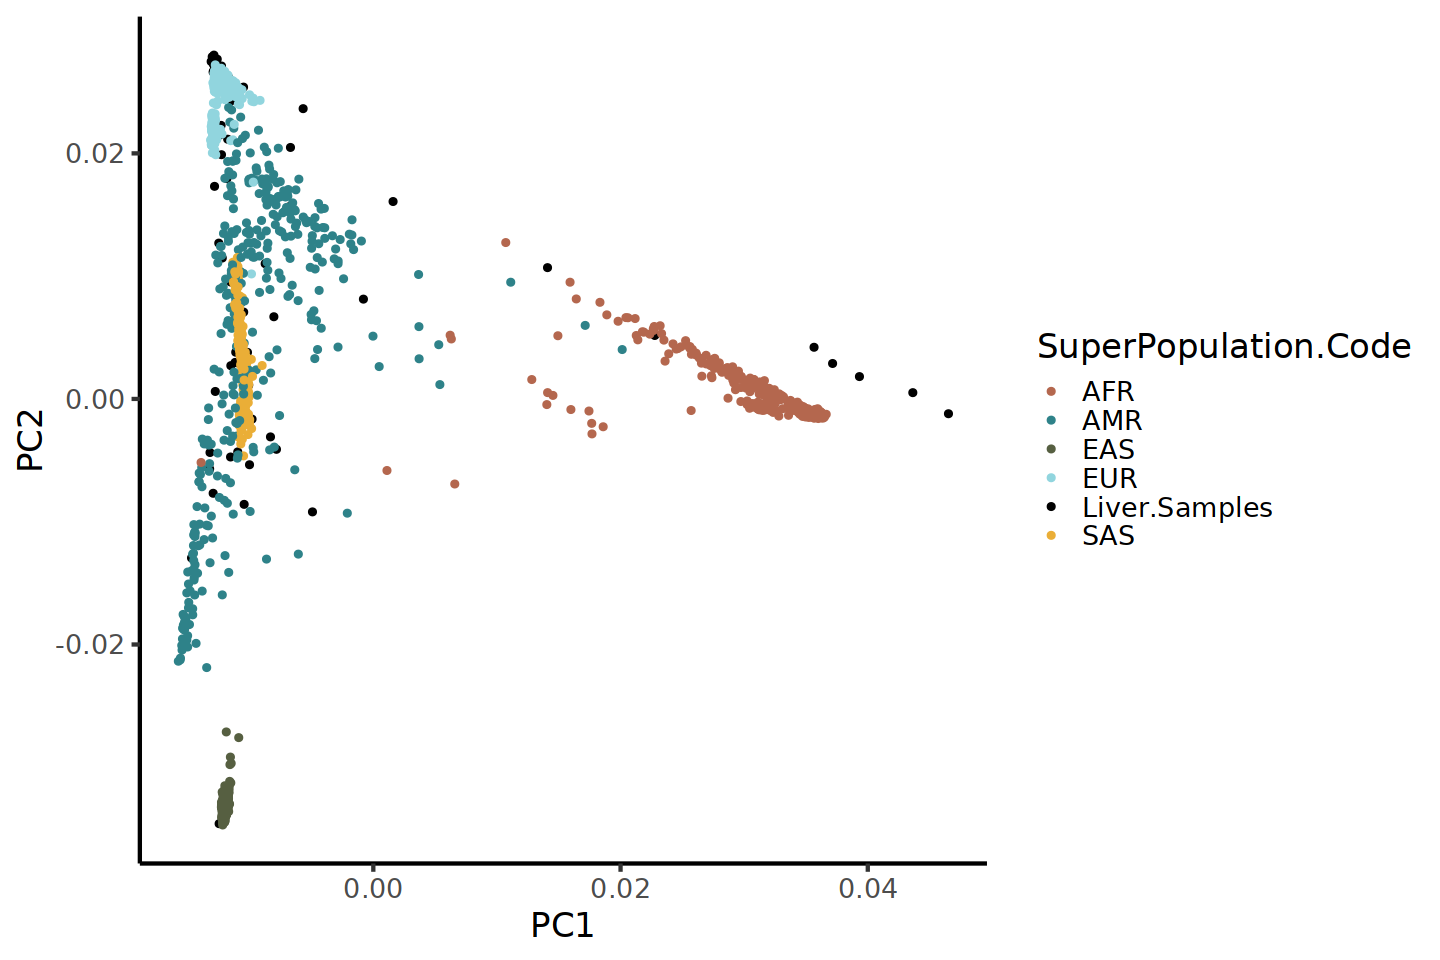

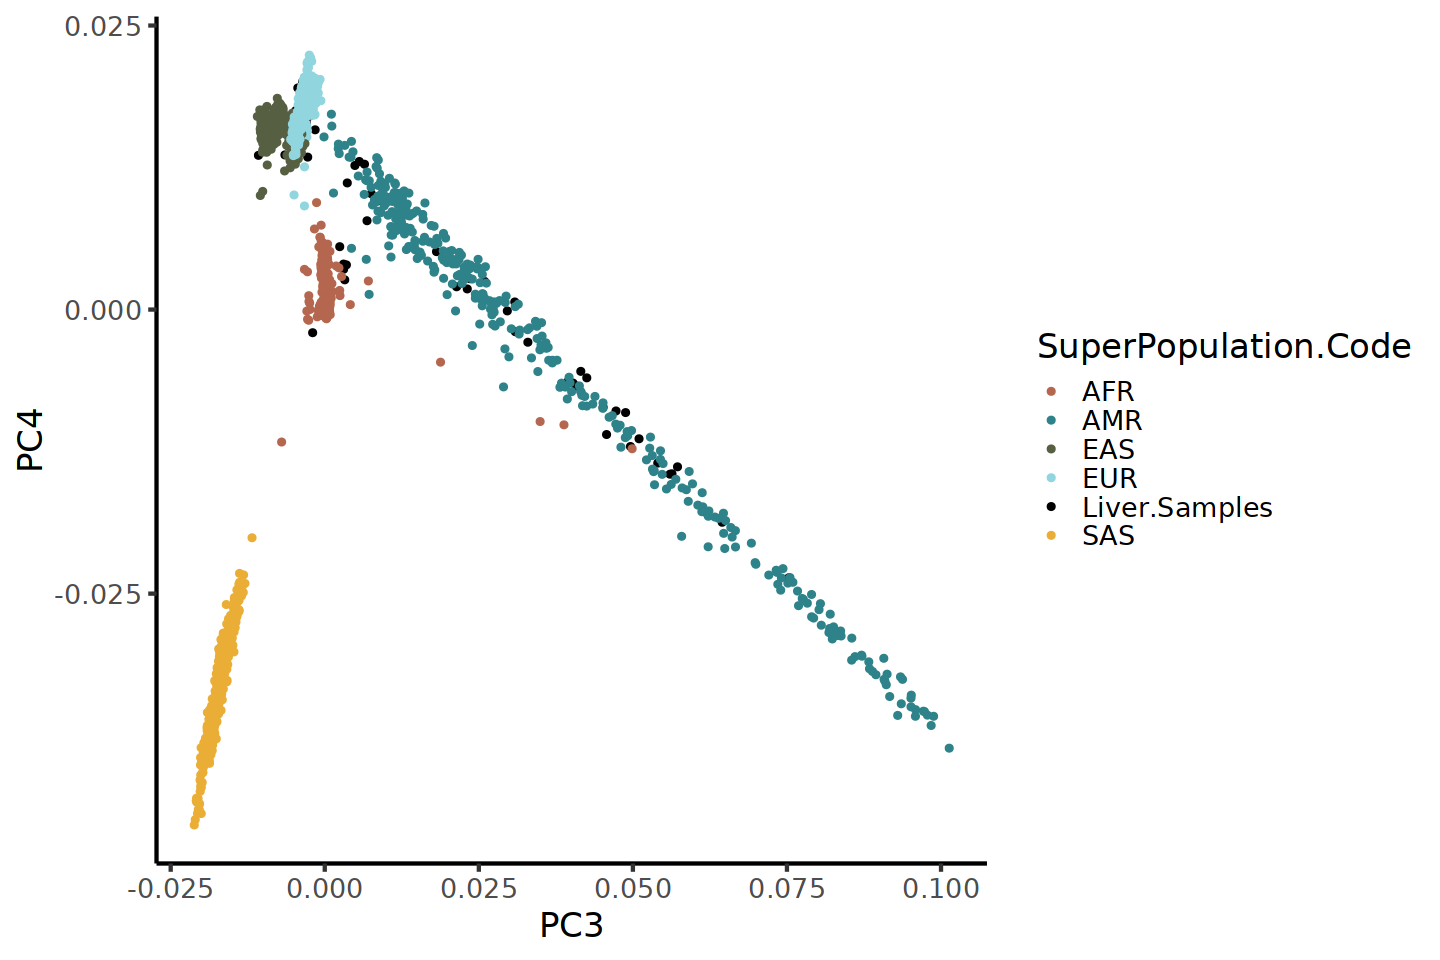

In [62]:
options(repr.plot.width=12, repr.plot.height=8)

ggplot(dplyr::left_join(pcas_new, samp2, dplyr::join_by(FID==Sample)), aes(x=PC1, y=PC2, color=SuperPopulation.Code)) +
    geom_point() + theme_classic(base_size=20) + scale_color_manual(values=colors)
ggplot(dplyr::left_join(pcas_new, samp2, dplyr::join_by(FID==Sample)), aes(x=PC3, y=PC4, color=SuperPopulation.Code)) +
    geom_point() + theme_classic(base_size=20) + scale_color_manual(values=colors)

Warning message:
“Removed 2548 rows containing missing values or values outside the scale range (`geom_text_repel()`).”
Warning message:
“ggrepel: 55 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“Removed 2548 rows containing missing values or values outside the scale range (`geom_text_repel()`).”
Warning message:
“ggrepel: 64 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


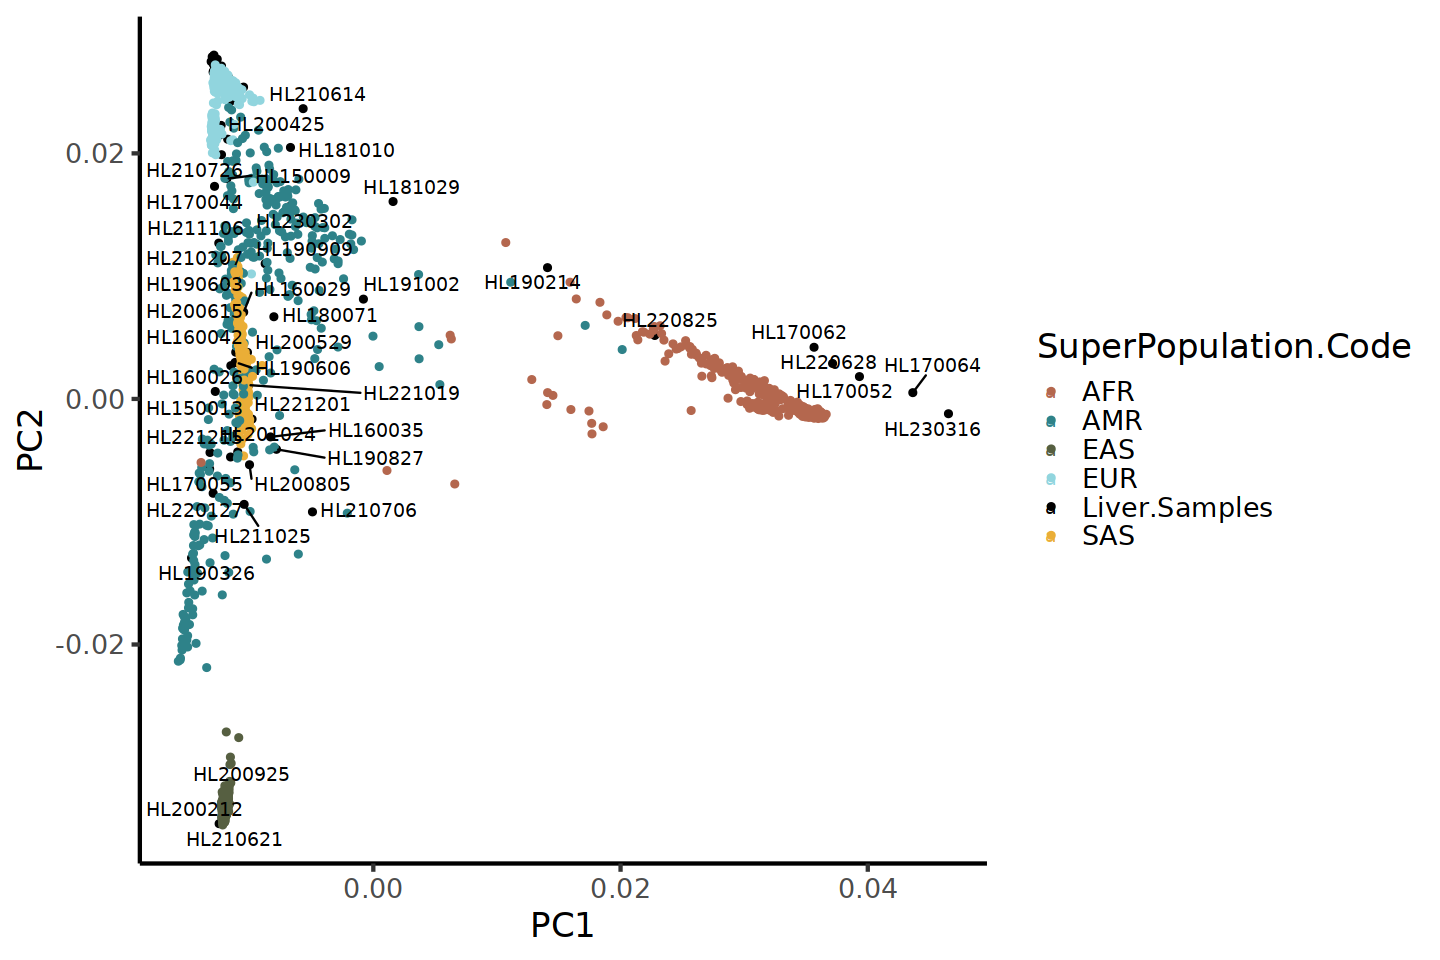

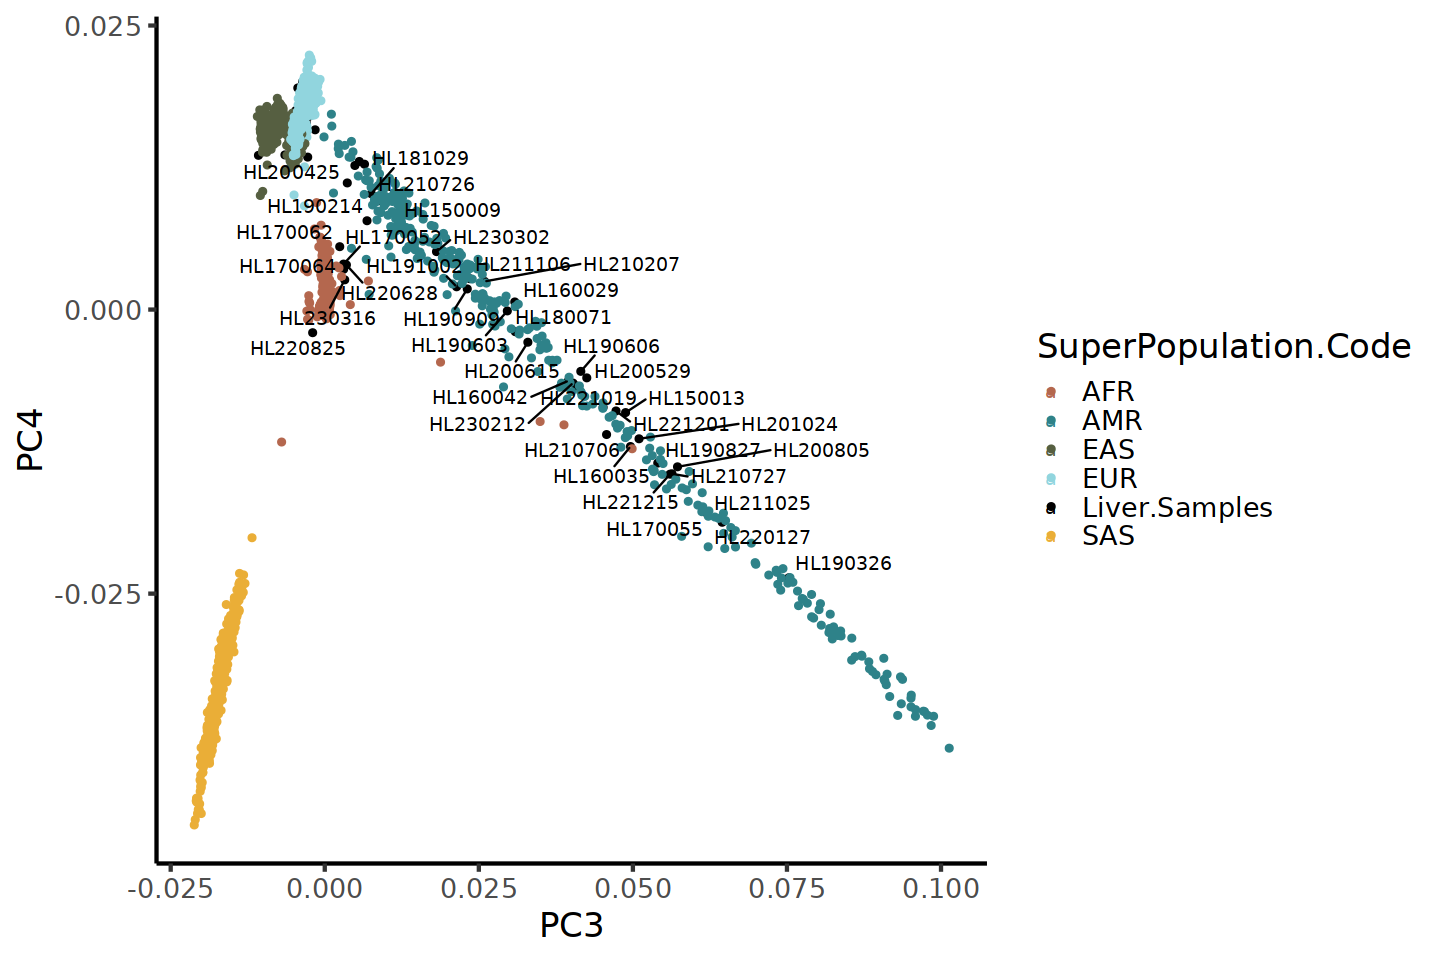

In [61]:
options(repr.plot.width=12, repr.plot.height=8)

ggplot(dplyr::left_join(pcas_new, samp2, dplyr::join_by(FID==Sample)), aes(x=PC1, y=PC2, color=SuperPopulation.Code, label=labs)) +
    geom_point() + geom_text_repel() + theme_classic(base_size=20) + scale_color_manual(values=colors)
ggplot(dplyr::left_join(pcas_new, samp2, dplyr::join_by(FID==Sample)), aes(x=PC3, y=PC4, color=SuperPopulation.Code, label=labs)) +
    geom_point() + geom_text_repel() + theme_classic(base_size=20) + scale_color_manual(values=colors)

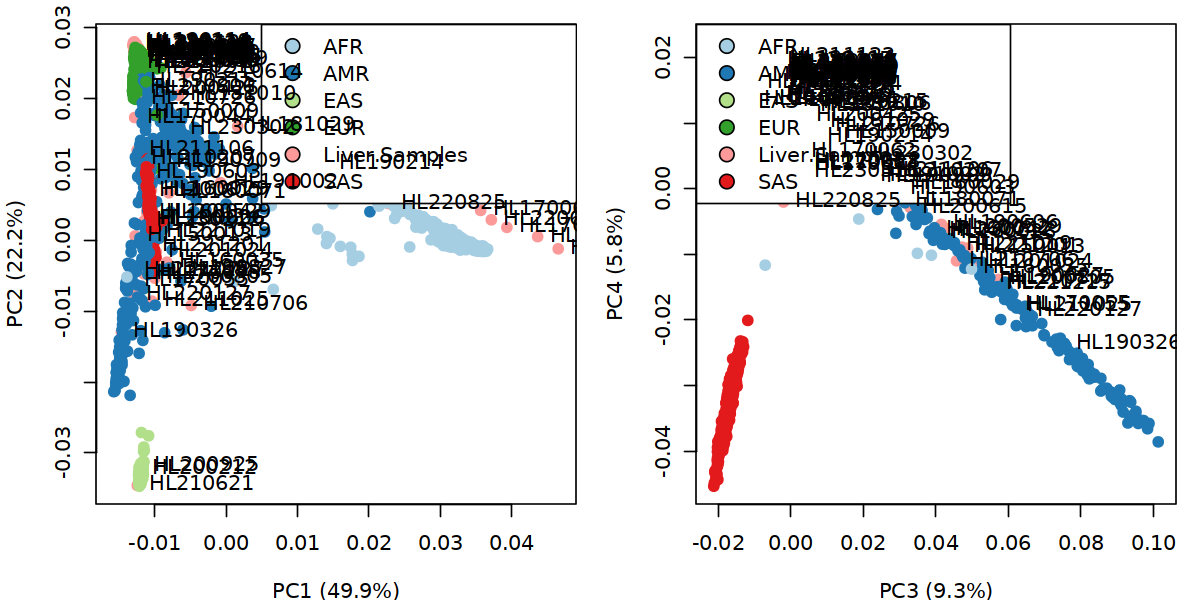

In [34]:
#Plot PCA and label our samples

options(repr.plot.width=10, repr.plot.height=5)
par(mfrow=c(1,2), mar=c(4,4,1,1))
plot(PC2~PC1, pcas_new, pch=19, col =  col[as.numeric(samp2$SuperPopulation.Code[match(pcas_new$IID, samp2$Sample)])], xlab=var_new_expl[1], ylab=var_new_expl[2])
legend("topright", legend = levels(samp2$SuperPopulation.Code), pch = 21, pt.bg = col, pt.cex=1.5, y.intersp = 1.6 )
text(pcas_new$PC1, pcas_new$PC2, labels = pcas_new$labs, pos = 4)

plot(PC4~PC3, pcas_new, pch=19, col =  col[as.numeric(samp2$SuperPopulation.Code[match(pcas_new$IID, samp2$Sample)])], xlab=var_new_expl[3], ylab=var_new_expl[4])
legend("topleft", legend = levels(samp2$SuperPopulation.Code), pch = 21, pt.bg = col , pt.cex=1.5, y.intersp = 1.6)
text(pcas_new$PC3, pcas_new$PC4, labels = pcas_new$labs, pos=4)
